In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
debashishsau_aslamerican_sign_language_aplhabet_dataset_path = kagglehub.dataset_download('debashishsau/aslamerican-sign-language-aplhabet-dataset')

print('Data source import complete.')

100%|██████████| 4.20G/4.20G [04:32<00:00, 16.5MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = debashishsau_aslamerican_sign_language_aplhabet_dataset_path
dataset_root = os.path.join(base_path, "ASL_Alphabet_Dataset")

train_dir = os.path.join(dataset_root, "asl_alphabet_train")

print("Train exists:", os.path.exists(train_dir))
print("Classes:", sorted(os.listdir(train_dir)))

Train exists: True
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [ ]:
import cv2
import numpy as np
from tqdm import tqdm

IMG_SIZE = 64

X = []
y = []

class_names = sorted(os.listdir(train_dir))

print("🚀 Extracting HOG features for Random Forest...")

for label, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)

    for img_name in tqdm(os.listdir(class_path), desc=class_name):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # HOG using skimage
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            visualize=False
        )

        X.append(features)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("✅ Feature extraction done")
print("X shape:", X.shape)

🚀 Extracting HOG features for Random Forest...


space: 100%|██████████| 7071/7071 [00:18<00:00, 388.76it/s]


✅ Feature extraction done
X shape: (223074, 1764)


In [ ]:
from collections import defaultdict

limit = 700
counter = defaultdict(int)

X_small, y_small = [], []

for xi, yi in zip(X, y):
    if counter[yi] < limit:
        X_small.append(xi)
        y_small.append(yi)
        counter[yi] += 1

X = np.array(X_small)
y = np.array(y_small)

print("Reduced shape:", X.shape)

Reduced shape: (20300, 1764)


In [ ]:
import os
import joblib
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# DATASET PATH
# -----------------------------
base_path = debashishsau_aslamerican_sign_language_aplhabet_dataset_path
dataset_root = os.path.join(base_path, "ASL_Alphabet_Dataset")
train_dir = os.path.join(dataset_root, "asl_alphabet_train")

# -----------------------------
# CLASS NAMES
# -----------------------------
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

# -----------------------------
# SPLIT DATA
# (Assumes X and y were created earlier)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# LOAD MODEL
# -----------------------------
rf_model = joblib.load("/content/drive/MyDrive/models/asl_random_forest.pkl")

# -----------------------------
# PREDICT
# -----------------------------
y_pred = rf_model.predict(X_test)

# -----------------------------
# CONVERT TO LABELS
# -----------------------------
predicted_labels = [class_names[i] for i in y_pred]
true_labels = [class_names[i] for i in y_test]

# -----------------------------
# METRICS
# -----------------------------
print("Accuracy:", accuracy_score(true_labels, predicted_labels))

print("\nClassification Report:\n")
print(classification_report(true_labels, predicted_labels, labels=class_names))



Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Accuracy: 0.9009852216748768

Classification Report:

              precision    recall  f1-score   support

           A       0.82      0.83      0.82       140
           B       0.92      0.88      0.90       140
           C       0.93      0.91      0.92       140
           D       0.95      0.93      0.94       140
           E       0.90      0.95      0.93       140
           F       0.96      0.96      0.96       140
           G       0.91      0.89      0.90       140
           H       0.93      0.90      0.92       140
           I       0.92      0.93      0.93       140
           J       0.91      0.98      0.94       140
           K       0.95      0.90      0.92       140
           L       0.93      0.96      0.95       140
           M       0.85      0.87      0.86       140
           N       0.8

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Classification report (structured)
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9009852216748768


In [ ]:
import json
import numpy as np

results = {
    "model_name": "Random_Forest_HOG",
    "accuracy": accuracy,
    "precision": report["macro avg"]["precision"],
    "recall": report["macro avg"]["recall"],
    "f1_score": report["macro avg"]["f1-score"]
}

# Save JSON
with open("rf_results.json", "w") as f:
    json.dump(results, f)

# Save confusion matrix
np.save("rf_confusion_matrix.npy", cm)

# Save class labels
np.save("rf_classes.npy", class_names)

print("✅ Random Forest results saved successfully")

✅ Random Forest results saved successfully


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

NameError: name 'y_val' is not defined

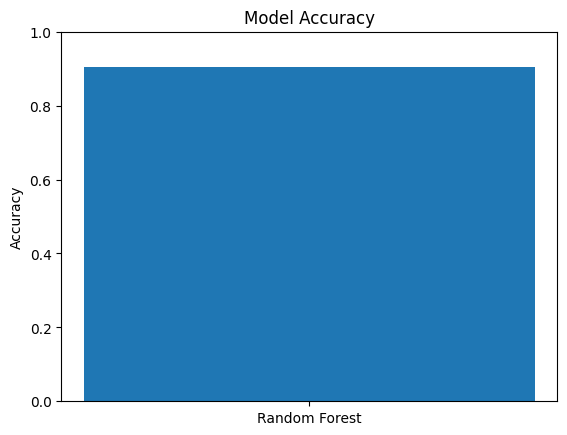

In [ ]:
plt.figure()

plt.bar(["Random Forest"], [acc])

plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.ylim(0,1)

plt.show()

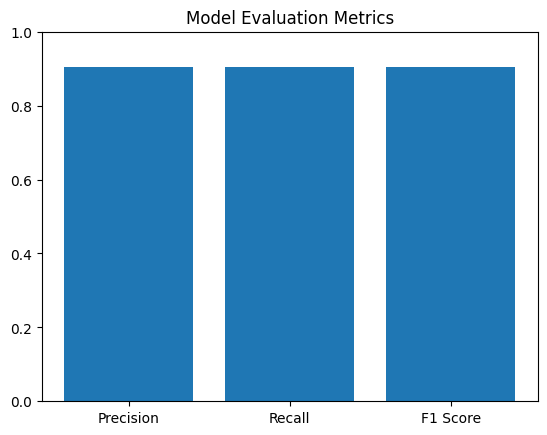

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_pred, average='macro')
recall = recall_score(y_val, y_pred, average='macro')
f1 = f1_score(y_val, y_pred, average='macro')

metrics = [precision, recall, f1]
labels = ["Precision", "Recall", "F1 Score"]

plt.figure()

plt.bar(labels, metrics)

plt.title("Model Evaluation Metrics")
plt.ylim(0,1)

plt.show()

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(rf_model, os.path.join(MODEL_DIR, "asl_random_forest.pkl"))
joblib.dump(class_names, os.path.join(MODEL_DIR, "asl_rf_classes.pkl"))

print("✅ Random Forest model & classes saved to Drive")

✅ Random Forest model & classes saved to Drive


In [ ]:
import joblib

rf_model = joblib.load("/content/drive/MyDrive/models/asl_random_forest.pkl")
class_names = joblib.load("/content/drive/MyDrive/models/asl_rf_classes.pkl")

print("✅ Random Forest model loaded")

✅ Random Forest model loaded


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 64

hog = cv2.HOGDescriptor(
    _winSize=(64, 64),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9
)

def extract_hog_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    features = hog.compute(img)
    return features.flatten()

In [ ]:
def predict_letter_rf(image_path):
    # Extract HOG features
    features = extract_hog_features(image_path)

    if features is None:
        print("❌ Cannot read image:", image_path)
        return None

    # Predict using Random Forest
    pred = rf_model.predict([features])[0]
    letter = class_names[pred]

    # Handle special ASL labels
    if letter == "space":
        print("🖼", image_path, "→ [SPACE]")
        return " "
    elif letter == "del":
        print("🖼", image_path, "→ [DELETE]")
        return None
    elif letter == "nothing":
        print("🖼", image_path, "→ [NOTHING]")
        return None
    else:
        print("🖼", image_path, "→", letter)
        return letter

In [ ]:
# images ka order (repeat allowed)
image_sequence = [
    "test1.jpeg",
    "test2.jpeg",
    "test2.jpeg",
    "test3.jpeg",
    "test4.jpeg"
]

word = ""

for image_path in image_sequence:

    letter = predict_letter_rf(image_path)

    if letter:
        word += letter

print("✅ Final Predicted Word:", word)

🖼 test1.jpeg → H
🖼 test2.jpeg → G
🖼 test2.jpeg → G
🖼 test3.jpeg → Y
🖼 test4.jpeg → L
✅ Final Predicted Word: HGGYL
